In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Data Loading & Cleaning
The Air Passengers dataset is loaded and inspected for missing values, duplicate records, invalid observations, and data types before performing time series analysis

In [2]:
#Load Dataset
df = pd.read_csv("AirPassengers.csv")
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [3]:
#Data Cleaning
#shape
print(df.shape)
#check for any missing values
print(df.isnull().sum())
#check for any duplicated rows
print(df.duplicated().sum())
#check for any invalid values
print((df['#Passengers']<0).sum())
# check the data types
print(df.dtypes)

(144, 2)
Month          0
#Passengers    0
dtype: int64
0
0
Month          object
#Passengers     int64
dtype: object


In [5]:
#converting 'Month' to Month
df['Month'] = pd.to_datetime(df['Month'])
print(df.dtypes)

Month          datetime64[ns]
#Passengers             int64
dtype: object


## 2. Time Series Visualization
The Time series is visualised to identify trend, seasonality, and variance behaviour before selecting an appropriate forecasting model.

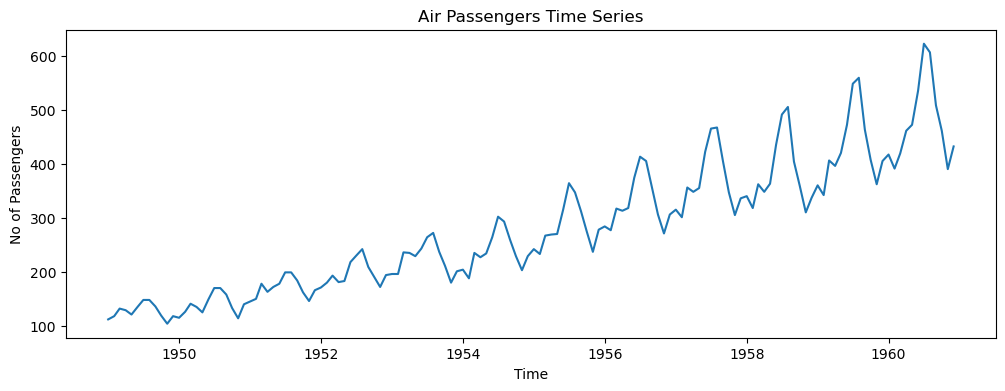

In [34]:
#visulalization
plt.figure(figsize=(12,4))
plt.plot(df['Month'],df['#Passengers'])
plt.title("Air Passengers Time Series")
plt.xlabel("Time")
plt.ylabel("No of Passengers")
plt.show()

Trend is present : The overall passenger count increases from around 100 to more than 600 over time
Seasonality is present : A repeating yearly pattern is clearly visible.Peaks and troughs occur at roughly the same months each year
Non constant variance:increasing the series is probably not stationary

## 3. Stationary Test(ADF)
The ADF test is performed to statistically determine whether the time series is stationary

In [7]:
# stationarity test : ADF Test
from statsmodels.tsa.stattools import adfuller
result = adfuller(df["#Passengers"])
print("ADF Statistics:",result[0])
print("p-value:",result[1])
for key,value in result[4].items():
    print(key,":",value)

ADF Statistics: 0.8153688792060472
p-value: 0.991880243437641
1% : -3.4816817173418295
5% : -2.8840418343195267
10% : -2.578770059171598


Since the p-value is greater than 0.05, the null hypothesis cannot be rejected. Therefore, the original series is non-stationary and requires differencing.

## 4. First-Order Differencing
First order differencing is applied to remove the long-term trend from the series

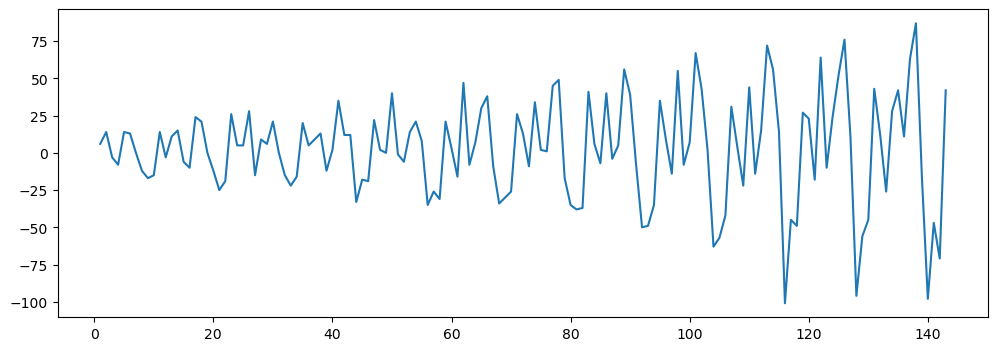

In [9]:
#first differencing
df["Passengers_diff1"] = df["#Passengers"].diff()
df["Passengers_diff1"].plot(figsize=(12,4))
plt.show()

Although the trend has been reduced, the series still exhibits seasonal behaviour. Therefore, seasonal differencing is required.

In [10]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df["Passengers_diff1"].dropna())
print("ADF Statistics:",result[0])
print("p-value:",result[1])
for key,value in result[4].items():
    print(key,":",value)

ADF Statistics: -2.8292668241699905
p-value: 0.05421329028382671
1% : -3.4816817173418295
5% : -2.8840418343195267
10% : -2.578770059171598


## 5. Seasonal Differencing
Since the AirPassengers dataset contains a yearly seasonal cycle, seasonal differencing with a lag of 12 is performed to remove the seasonal component

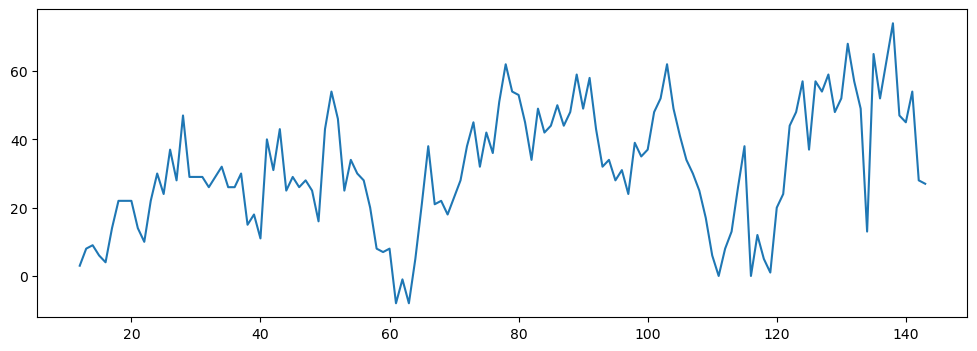

In [16]:
#still its border level trend removed seasonality still present 12 months so we enetrred into SARIMA
df['Passengers_diff2']=df['#Passengers'].diff(12)
df['Passengers_diff2'].plot(figsize=(12,4))
plt.show()

In [17]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df["Passengers_diff2"].dropna())
print("ADF Statistics:",result[0])
print("p-value:",result[1])
for key,value in result[4].items():
    print(key,":",value)

ADF Statistics: -3.3830207264924814
p-value: 0.011551493085514952
1% : -3.4816817173418295
5% : -2.8840418343195267
10% : -2.578770059171598


## 6. ACF and PACF analysis
The ACF and PACF plots are examined to obtain an intial understanding of the autoregressive and moving-average behaviour of the stationary series. These plots provide guidance for selecting candidate SARIMA parameters.

<Figure size 1200x400 with 0 Axes>

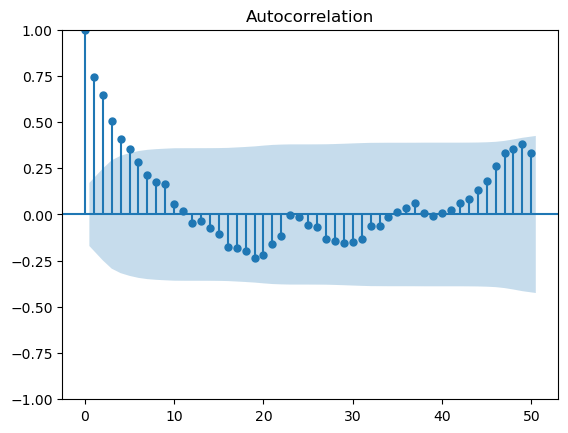

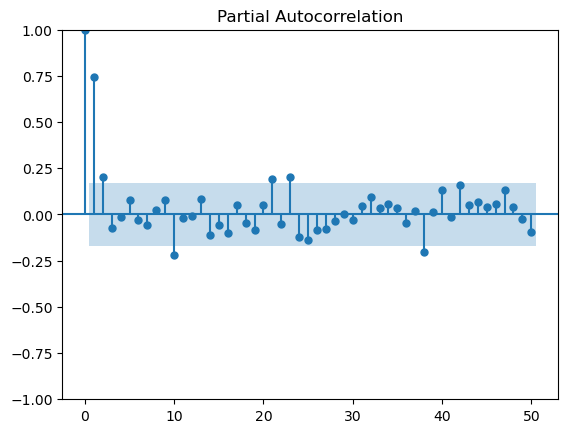

In [18]:
#plot pacf and acf
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
plt.figure(figsize =(12,4))
plot_acf(df['Passengers_diff2'].dropna(),lags =50)
plt.show()
plot_pacf(df['Passengers_diff2'].dropna(),lags =50)
plt.show()

## 7. SARIMA Parameter Selection Using Grid Search
A grid search is performed over multiple combinations of non-seasonal and seasonal parameters. The optimal model is selected using the lowest AIC and BIC.

In [19]:
#storage 
results =[]
best_aic = float('inf')
best_bic = float('inf')
best_aic_order = None
best_bic_order = None

In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")
for p in range(3):
    for q in range(3):
        for P in range(2):
            for Q in range(2):
                try:
                    model = SARIMAX(df['#Passengers'],order =(p,1,q), seasonal_order =(P,1,Q,12))
                    fit = model.fit(disp=False)
                    aic = fit.aic
                    bic = fit.bic
                    results.append([p,q,P,Q,aic,bic])
                    print(f"SARIMA ({p},1,{q})({P},1,{Q},12) AIC={aic:.2f} BIC ={bic:.2f}")
                    if aic<best_aic:
                        best_aic = aic
                        best_aic_order =(p,q,P,Q)
                    if bic<best_bic:
                        best_bic = bic
                        best_bic_order =(p,q,P,Q)
                except Exception as e:
                    print(f"SARIMA({p},1,{q})({P},1,{Q},12) failed: {e}")
print("Best AIC Model:", best_aic_order)
print("Best AIC:", best_aic)

print("\nBest BIC Model:", best_bic_order)
print("Best BIC:", best_bic)                    

SARIMA (0,1,0)(0,1,0,12) AIC=1031.51 BIC =1034.38
SARIMA (0,1,0)(0,1,1,12) AIC=1030.75 BIC =1036.50
SARIMA (0,1,0)(1,1,0,12) AIC=1030.41 BIC =1036.16
SARIMA (0,1,0)(1,1,1,12) AIC=1032.13 BIC =1040.75
SARIMA (0,1,1)(0,1,0,12) AIC=1020.64 BIC =1026.39
SARIMA (0,1,1)(0,1,1,12) AIC=1021.00 BIC =1029.63
SARIMA (0,1,1)(1,1,0,12) AIC=1020.42 BIC =1029.05
SARIMA (0,1,1)(1,1,1,12) AIC=1020.33 BIC =1031.83
SARIMA (0,1,2)(0,1,0,12) AIC=1022.63 BIC =1031.25
SARIMA (0,1,2)(0,1,1,12) AIC=1023.00 BIC =1034.50
SARIMA (0,1,2)(1,1,0,12) AIC=1022.42 BIC =1033.93
SARIMA (0,1,2)(1,1,1,12) AIC=1022.32 BIC =1036.70
SARIMA (1,1,0)(0,1,0,12) AIC=1020.39 BIC =1026.14
SARIMA (1,1,0)(0,1,1,12) AIC=1020.91 BIC =1029.54
SARIMA (1,1,0)(1,1,0,12) AIC=1020.39 BIC =1029.02
SARIMA (1,1,0)(1,1,1,12) AIC=1020.49 BIC =1031.99
SARIMA (1,1,1)(0,1,0,12) AIC=1022.39 BIC =1031.02
SARIMA (1,1,1)(0,1,1,12) AIC=1022.90 BIC =1034.40
SARIMA (1,1,1)(1,1,0,12) AIC=1022.36 BIC =1033.86
SARIMA (1,1,1)(1,1,1,12) AIC=1022.30 BIC =1036.67


Based on the grid search results, SARIMA(2,1,1)(0,1,0,12) achieved the lowest AIC value and was selected as the final forecasting model.

## 8. Final SARIMA Model
The optimal SARIMA Model identified through the grid search is fitted to the complete dataset. The model summary provides the estimated coefficients, standard errors, information criteria, and of statistical significance of the fitted parameters.

In [21]:
#fit final model
final_model = SARIMAX(df['#Passengers'],order =(2,1,1),seasonal_order =(0,1,0,12)).fit()
print(final_model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                         #Passengers   No. Observations:                  144
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -504.923
Date:                             Sun, 28 Jun 2026   AIC                           1017.847
Time:                                     10:37:30   BIC                           1029.348
Sample:                                          0   HQIC                          1022.520
                                             - 144                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5960      0.085      6.987      0.000       0.429       0.763
ar.L2          0.2143      

## 9. Residual Diagnostics
Residual diagnostics are performed to evaluate whether the fitted model adequately captures the underlying structure of the time series. A good forecasting model should produce residuals that behave like white noise, indicating that no systematic information remains unexplained.

count    144.000000
mean       1.763764
std       15.446277
min      -59.003446
25%       -6.227461
50%        0.360216
75%       10.427651
max      112.000000
dtype: float64


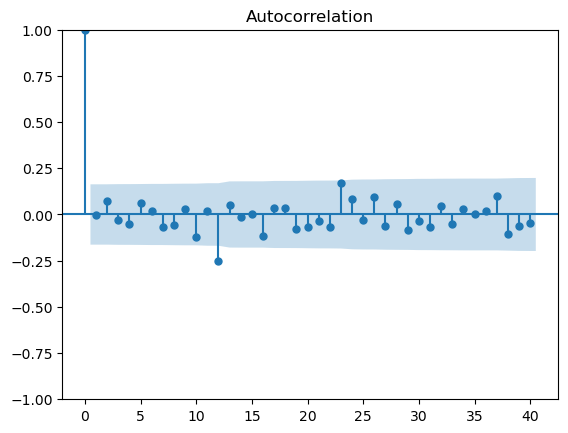

In [22]:
residuals = final_model.resid
print(residuals.describe())
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals,lags =40)
plt.show()

The residual auto correlation plot shows that nearly all autocorrelation coefficients lie within the 95% confidence interval, indicating that the residuals do not exhibit significant autocorrelation.

## 10. Ljung- Box output
The Ljung–Box test is performed to statistically verify whether the residuals are independently distributed. A p-value greater than 0.05 indicates that the residuals are approximately white noise.

In [23]:
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(residuals,lags =[10,20,24],return_df =True)
print(lb)

      lb_stat  lb_pvalue
10   5.583009   0.848997
20  20.712010   0.414254
24  27.996037   0.260207


Since the Ljung–Box test produces p-values greater than 0.05 at all examined lags, the null hypothesis cannot be rejected. This indicates that no significant autocorrelation remains in the residuals, suggesting that the fitted SARIMA model is adequate.

## 11. Final Conclusion

The AirPassengers dataset exhibited a clear upward trend and strong yearly seasonality, indicating that a Seasonal ARIMA (SARIMA) model was appropriate for forecasting.

After applying seasonal differencing, the series became stationary, as confirmed by the Augmented Dickey–Fuller (ADF) test. A grid search was then performed to identify the optimal model, and SARIMA(2,1,1)(0,1,0,12) was selected based on the lowest AIC value.

Residual diagnostics, including the residual ACF plot and Ljung–Box test, showed no significant autocorrelation in the residuals. Therefore, the residuals can be considered approximately white noise, indicating that the fitted SARIMA model adequately captures the underlying structure of the AirPassengers time series.